--------------------------------------
RELATÓRIO DE SAÚDE TÉRMICA DO SATÉLITE
Total de leituras válidas analisadas: 46
--------------------------------------
Distribuição de Estágios Térmicos
  Cold Case Crítico: 14 amostra(s)
  Frio (Atenção): 2 amostra(s)
  Nominal (Ideal): 13 amostra(s)
  Quente (Atenção): 4 amostra(s)
  Hot Case Crítico: 13 amostra(s)
--------------------------------------
Análise de Inversão de Tendência
    Picos detectados (Índice da amostra, Temp °C): [(13, 98), (39, 99)]
    Vales detectados (Índice da amostra, Temp °C): [(26, -91)]
--------------------------------------
Diagnóstico Final
   ESTADO: CRÍTICO.
   Justificativa: O satélite registrou temperaturas extremas fora da faixa de segurança (-40°C a 70°C).
   Risco de danos permanentes, degradação de componentes ou trincas estruturais.


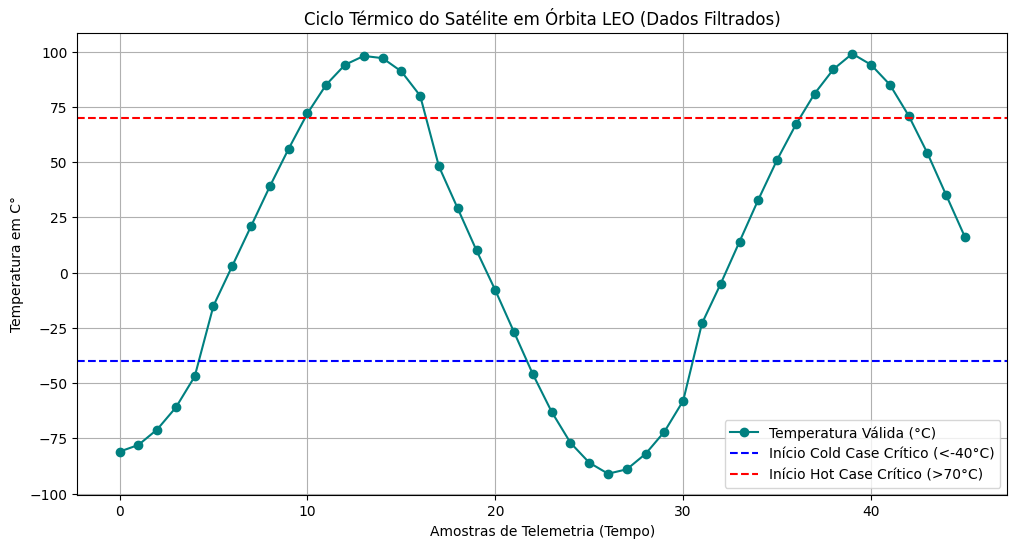

In [ ]:
import matplotlib.pyplot as plt

temperaturas = [-81, -78, -71, -61, -47, 180, -15, 3, 21, 39,
56, 72, 85, 94, 98, 97, 91, 80, -150, 48,
29, 10, -8, -27, -46, -63, -77, -86, -91, -89,
-82, -72, -58, 200, -23, -5, 14, 33, 51, 67,
81, 92, -130, 99, 94, 85, 71, 54, 35, 16]
def validar_temperatura(t):
    return -100 <= t <= 120

def classificar_termica(t):
    if t < -40:
        return "Cold Case Crítico", "Alerta de Falha Imediata"
    elif -40 <= t < -20:
        return "Frio (Atenção)", "Ligar Aquecedores"
    elif -20 <= t <= 50:
        return "Nominal (Ideal)", "Operação Padrão"
    elif 50 < t <= 70:
        return "Quente (Atenção)", "Desligar Cargas Úteis"
    else: # t > 70
        return "Hot Case Crítico", "Alerta de Degradação"

def detectar_picos_vales(lista):
    picos = []
    vales = []
    for i in range(1, len(lista) - 1):
        if lista[i] > lista[i - 1] and lista[i] > lista[i + 1]:
            picos.append((i, lista[i]))
        elif lista[i] < lista[i - 1] and lista[i] < lista[i + 1]:
            vales.append((i, lista[i]))
    return picos, vales

def gerar_relatorio(lista):
    print('--------------------------------------')
    print("RELATÓRIO DE SAÚDE TÉRMICA DO SATÉLITE")
    classificacoes = {"Cold Case Crítico": 0,
        "Frio (Atenção)": 0,
        "Nominal (Ideal)": 0,
        "Quente (Atenção)": 0,
        "Hot Case Crítico": 0}
    for t in lista:
        categoria, acao = classificar_termica(t)
        classificacoes[categoria] += 1
    print(f"Total de leituras válidas analisadas: {len(lista)}")
    print('--------------------------------------')
    print("Distribuição de Estágios Térmicos")
    for cat, qtd in classificacoes.items():
        print(f"  {cat}: {qtd} amostra(s)")

    picos, vales = detectar_picos_vales(lista)
    print('--------------------------------------')
    print("Análise de Inversão de Tendência")
    print(f"    Picos detectados (Índice da amostra, Temp °C): {picos if picos else 'Nenhum'}")
    print(f"    Vales detectados (Índice da amostra, Temp °C): {vales if vales else 'Nenhum'}")
    print('--------------------------------------')
    print("Diagnóstico Final")
    if classificacoes["Cold Case Crítico"] > 4 or classificacoes["Hot Case Crítico"] > 4:
        print("   ESTADO: CRÍTICO.")
        print("   Justificativa: O satélite registrou temperaturas extremas fora da faixa de segurança (-40°C a 70°C).")
        print("   Risco de danos permanentes, degradação de componentes ou trincas estruturais.")
    else:
        print("   ESTADO: SEGURO.")
        print("   Justificativa: Todas as leituras filtradas encontram-se em níveis aceitáveis e sob ações de controle previstas.")

temperaturas_validas = []
for t in temperaturas:
  if validar_temperatura(t):
    temperaturas_validas.append(t)

gerar_relatorio(temperaturas_validas)

plt.figure(figsize=(12, 6))
plt.plot(temperaturas_validas, marker='o', linestyle='-', color='teal', label='Temperatura Válida (°C)')

plt.axhline(y=-40, color='blue', linestyle='--', linewidth=1.5, label='Início Cold Case Crítico (<-40°C)')
plt.axhline(y=70, color='red', linestyle='--', linewidth=1.5, label='Início Hot Case Crítico (>70°C)')

plt.title('Ciclo Térmico do Satélite em Órbita LEO (Dados Filtrados)')
plt.xlabel('Amostras de Telemetria (Tempo)')
plt.ylabel('Temperatura em C°')
plt.legend()
plt.grid()

plt.show()